In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

y,z,r = np.loadtxt("scanData/scan_yz_20260604_122343.csv", delimiter=",", skiprows=1, unpack=True)
mask = (y != 0)

In [5]:
import sys
print(sys.executable)

/Users/lingwen/Desktop/PhD/QWM Github/QWM/RenSciPiezo/.venv/bin/python


In [23]:
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

# zigzag scan plotter
def plotZigzag2DScan(filepath, resolution=200, cmap='inferno', targetYPositionOffset=0, targetZPositionOffset=0, targetYSpan=0, targetZSpan=0):
    # Load data
    df = pd.read_csv(filepath)
    y = df['y_mm'].values
    z = df['z_mm'].values
    r = df['r'].values
    startY = df['start_y_mm'].values[0]
    startZ = df['start_z_mm'].values[0]

    # Mask zeros and convert to microns
    mask = (y != 0)
    y_um = (y[mask] - y[mask].min()) * 1000
    z_um = (z[mask] - z[mask].min()) * 1000
    r_uV = r[mask] * 1e6  # convert to µV

    # Starting position in micron coordinates
    startY_um = (startY - y[mask].min()) * 1000
    startZ_um = (startZ - z[mask].min()) * 1000

    # Interpolate onto regular grid
    y_grid, z_grid = np.meshgrid(np.linspace(y_um.min(), y_um.max(), resolution),
                                  np.linspace(z_um.min(), z_um.max(), resolution))
    R_grid = griddata((y_um, z_um), r_uV, (y_grid, z_grid), method='linear')

    # Plot
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(R_grid,
                   extent=[y_um.min(), y_um.max(), z_um.min(), z_um.max()],
                   origin='lower',
                   aspect='equal',
                   cmap=cmap)

    # Colorbar same height as plot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label('Photovoltage (µV)')

    # Mark starting position
    ax.plot(startY_um, startZ_um, 'w+', markersize=15, markeredgewidth=3)
    ax.plot(startY_um, startZ_um, 'r*', markersize=10, markerfacecolor='none', markeredgewidth=2, label='Start')

    if targetZPositionOffset != 0 or targetYPositionOffset != 0:
        targetY_um = startY_um + targetYPositionOffset
        targetZ_um = startZ_um + targetZPositionOffset
        ax.plot(targetY_um, targetZ_um, 'w+', markersize=15, markeredgewidth=3)
        ax.plot(targetY_um, targetZ_um, 'b*', markersize=10, markerfacecolor='none', markeredgewidth=2, label='Target')

        if targetYSpan != 0 and targetZSpan != 0:
            box = Rectangle(
                (targetY_um - targetYSpan/2, targetZ_um - targetZSpan/2),
                targetYSpan, targetZSpan,
                linewidth=1.5, edgecolor='cyan', facecolor='none', linestyle='--', label='Target area'
            )
            ax.add_patch(box)

    ax.legend(fontsize=8)
    ax.set_xlabel('Y Position (µm)')
    ax.set_ylabel('Z Position (µm)')
    ax.set_title(f'Zigzag-Y 2D Scan: Photovoltage Map (interpolated data)\n{filepath}')
    plt.tight_layout()
    plt.show()

    print(f"   Total points loaded: {len(r_uV)}")
    print(f"   Y range: {y_um.min():.2f} to {y_um.max():.2f} µm")
    print(f"   Z range: {z_um.min():.2f} to {z_um.max():.2f} µm")
    print(f"   R range: {r_uV.min():.2f} to {r_uV.max():.2f} µV")
    print(f"   Scan center position: Y={startY:.3f} mm, Z={startZ:.3f} mm")
    if targetZPositionOffset != 0 or targetYPositionOffset != 0:
        print(f"   Scan target position: Y={startY + targetYPositionOffset*1e-3:.3f} mm, Z={startZ + targetZPositionOffset*1e-3:.3f} mm")
    if targetYSpan != 0 and targetZSpan != 0:
        print(f"   Target box: Y span={targetYSpan:.2f} µm, Z span={targetZSpan:.2f} µm")


def plotZigzag2DScanPcolormesh(filepath, cmap='viridis', targetYPositionOffset=0, targetZPositionOffset=0, targetYSpan=0, targetZSpan=0):
    # Load data
    df = pd.read_csv(filepath)
    y = df['y_mm'].values
    z = df['z_mm'].values
    r = df['r'].values
    n_y = int(df['n_y'].values[0])
    n_z = int(df['n_z'].values[0])
    startY = df['start_y_mm'].values[0]
    startZ = df['start_z_mm'].values[0]

    print(f"   Grid: {n_y} x {n_z} = {n_y*n_z}, data points: {len(r)}")

    Y = y.reshape(n_z, n_y).copy()
    Z = z.reshape(n_z, n_y).copy()
    R = r.reshape(n_z, n_y).copy() * 1e6  # convert to µV

    # Snake correction
    Y[1::2, :] = Y[1::2, ::-1]
    Z[1::2, :] = Z[1::2, ::-1]
    R[1::2, :] = R[1::2, ::-1]

    # Sort every row by actual Y position
    for i in range(n_z):
        sort_idx = np.argsort(Y[i, :])
        Y[i, :] = Y[i, sort_idx]
        Z[i, :] = Z[i, sort_idx]
        R[i, :] = R[i, sort_idx]

    # Convert to microns
    Y_um = (Y - Y.min()) * 1000
    Z_um = (Z - Z.min()) * 1000
    startY_um = (startY - y.min()) * 1000
    startZ_um = (startZ - z.min()) * 1000

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.pcolormesh(Y_um, Z_um, R, shading='auto', cmap=cmap)
    ax.set_aspect('equal')

    # Colorbar same height as plot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label('Photovoltage (µV)')

    # Mark starting position
    ax.plot(startY_um, startZ_um, 'w+', markersize=15, markeredgewidth=3)
    ax.plot(startY_um, startZ_um, 'r*', markersize=10, markerfacecolor='none', markeredgewidth=2, label='Start')

    if targetZPositionOffset != 0 or targetYPositionOffset != 0:
        targetY_um = startY_um + targetYPositionOffset
        targetZ_um = startZ_um + targetZPositionOffset
        ax.plot(targetY_um, targetZ_um, 'w+', markersize=15, markeredgewidth=3)
        ax.plot(targetY_um, targetZ_um, 'b*', markersize=10, markerfacecolor='none', markeredgewidth=2, label='Target')

        if targetYSpan != 0 and targetZSpan != 0:
            box = Rectangle(
                (targetY_um - targetYSpan/2, targetZ_um - targetZSpan/2),
                targetYSpan, targetZSpan,
                linewidth=1.5, edgecolor='cyan', facecolor='none', linestyle='--', label='Target area'
            )
            ax.add_patch(box)

    ax.legend(fontsize=8)
    ax.set_xlabel('Y Position (µm)')
    ax.set_ylabel('Z Position (µm)')
    ax.set_title(f'Zigzag-Y 2D Scan: Photovoltage Map (raw data)\n{filepath}')
    plt.tight_layout()
    plt.show()

    print(f"   Y range: {Y_um.min():.2f} to {Y_um.max():.2f} µm")
    print(f"   Z range: {Z_um.min():.2f} to {Z_um.max():.2f} µm")
    print(f"   R range: {R.min():.2f} to {R.max():.2f} µV")
    print(f"   Scan center position: Y={startY:.3f} mm, Z={startZ:.3f} mm")
    if targetZPositionOffset != 0 or targetYPositionOffset != 0:
        print(f"   Scan target position: Y={startY + targetYPositionOffset*1e-3:.3f} mm, Z={startZ + targetZPositionOffset*1e-3:.3f} mm")
    if targetYSpan != 0 and targetZSpan != 0:
        print(f"   Target box: Y span={targetYSpan:.2f} µm, Z span={targetZSpan:.2f} µm")

In [26]:
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

# linear scan plotter
def plotLinear2DScan(filepath, resolution=200, cmap='inferno', targetYPositionOffset=0, targetZPositionOffset=0, targetYSpan=0, targetZSpan=0):
    # Load data
    df = pd.read_csv(filepath)
    y = df['y_mm'].values
    z = df['z_mm'].values
    r = df['r'].values
    startY = df['start_y_mm'].values[0]
    startZ = df['start_z_mm'].values[0]

    # Mask zeros and convert to microns
    mask = (y != 0)
    y_um = (y[mask] - y[mask].min()) * 1000
    z_um = (z[mask] - z[mask].min()) * 1000
    r_uV = r[mask] * 1e6  # convert to µV

    # Starting position in micron coordinates
    startY_um = (startY - y[mask].min()) * 1000
    startZ_um = (startZ - z[mask].min()) * 1000

    # Interpolate onto regular grid
    y_grid, z_grid = np.meshgrid(np.linspace(y_um.min(), y_um.max(), resolution),
                                  np.linspace(z_um.min(), z_um.max(), resolution))
    R_grid = griddata((y_um, z_um), r_uV, (y_grid, z_grid), method='linear')

    # Plot
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(R_grid,
                   extent=[y_um.min(), y_um.max(), z_um.min(), z_um.max()],
                   origin='lower',
                   aspect='equal',
                   cmap=cmap)

    # Colorbar same height as plot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label('Photovoltage (µV)')

    # Mark starting position
    ax.plot(startY_um, startZ_um, 'w+', markersize=15, markeredgewidth=3)
    ax.plot(startY_um, startZ_um, 'r*', markersize=10, markerfacecolor='none', markeredgewidth=2, label='Start')

    if targetZPositionOffset != 0 or targetYPositionOffset != 0:
        targetY_um = startY_um + targetYPositionOffset
        targetZ_um = startZ_um + targetZPositionOffset
        ax.plot(targetY_um, targetZ_um, 'w+', markersize=15, markeredgewidth=3)
        ax.plot(targetY_um, targetZ_um, 'b*', markersize=10, markerfacecolor='none', markeredgewidth=2, label='Target')

        if targetYSpan != 0 and targetZSpan != 0:
            box = Rectangle(
                (targetY_um - targetYSpan/2, targetZ_um - targetZSpan/2),
                targetYSpan, targetZSpan,
                linewidth=1.5, edgecolor='cyan', facecolor='none', linestyle='--', label='Target area'
            )
            ax.add_patch(box)

    ax.legend(fontsize=8)
    ax.set_xlabel('Y Position (µm)')
    ax.set_ylabel('Z Position (µm)')
    ax.set_title(f'Linear-Y 2D Scan: Photovoltage Map (interpolated data)\n{filepath}')
    plt.tight_layout()
    plt.show()

    print(f"   Total points loaded: {len(r_uV)}")
    print(f"   Y range: {y_um.min():.2f} to {y_um.max():.2f} µm")
    print(f"   Z range: {z_um.min():.2f} to {z_um.max():.2f} µm")
    print(f"   R range: {r_uV.min():.2f} to {r_uV.max():.2f} µV")
    print(f"   Scan center position: Y={startY:.3f} mm, Z={startZ:.3f} mm")
    if targetZPositionOffset != 0 or targetYPositionOffset != 0:
        print(f"   Scan target position: Y={startY + targetYPositionOffset*1e-3:.3f} mm, Z={startZ + targetZPositionOffset*1e-3:.3f} mm")
    if targetYSpan != 0 and targetZSpan != 0:
        print(f"   Target box: Y span={targetYSpan:.2f} µm, Z span={targetZSpan:.2f} µm")


def plotLinear2DScanPcolormesh(filepath, cmap='viridis', targetYPositionOffset=0, targetZPositionOffset=0, targetYSpan=0, targetZSpan=0):
    # Load data
    df = pd.read_csv(filepath)
    y = df['y_mm'].values
    z = df['z_mm'].values
    r = df['r'].values
    n_y = int(df['n_y'].values[0])
    n_z = int(df['n_z'].values[0])
    startY = df['start_y_mm'].values[0]
    startZ = df['start_z_mm'].values[0]

    print(f"   Grid: {n_y} x {n_z} = {n_y*n_z}, data points: {len(r)}")

    Y = y.reshape(n_z, n_y).copy()
    Z = z.reshape(n_z, n_y).copy()
    R = r.reshape(n_z, n_y).copy() * 1e6  # convert to µV

    # No snake correction needed — linear scan always goes same direction

    # Convert to microns
    Y_um = (Y - Y.min()) * 1000
    Z_um = (Z - Z.min()) * 1000
    startY_um = (startY - y.min()) * 1000
    startZ_um = (startZ - z.min()) * 1000

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.pcolormesh(Y_um, Z_um, R, shading='auto', cmap=cmap)
    ax.set_aspect('equal')

    # Colorbar same height as plot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label('Photovoltage (µV)')

    # Mark starting position
    ax.plot(startY_um, startZ_um, 'w+', markersize=15, markeredgewidth=3)
    ax.plot(startY_um, startZ_um, 'r*', markersize=10, markerfacecolor='none', markeredgewidth=2, label='Start')

    if targetZPositionOffset != 0 or targetYPositionOffset != 0:
        targetY_um = startY_um + targetYPositionOffset
        targetZ_um = startZ_um + targetZPositionOffset
        ax.plot(targetY_um, targetZ_um, 'w+', markersize=15, markeredgewidth=3)
        ax.plot(targetY_um, targetZ_um, 'b*', markersize=10, markerfacecolor='none', markeredgewidth=2, label='Target')

        if targetYSpan != 0 and targetZSpan != 0:
            box = Rectangle(
                (targetY_um - targetYSpan/2, targetZ_um - targetZSpan/2),
                targetYSpan, targetZSpan,
                linewidth=1.5, edgecolor='cyan', facecolor='none', linestyle='--', label='Target area'
            )
            ax.add_patch(box)

    ax.legend(fontsize=8)
    ax.set_xlabel('Y Position (µm)')
    ax.set_ylabel('Z Position (µm)')
    ax.set_title(f'Linear-Y 2D Scan: Photovoltage Map (raw data)\n{filepath}')
    plt.tight_layout()
    plt.show()

    print(f"   Y range: {Y_um.min():.2f} to {Y_um.max():.2f} µm")
    print(f"   Z range: {Z_um.min():.2f} to {Z_um.max():.2f} µm")
    print(f"   R range: {R.min():.2f} to {R.max():.2f} µV")
    print(f"   Scan center position: Y={startY:.3f} mm, Z={startZ:.3f} mm")
    if targetZPositionOffset != 0 or targetYPositionOffset != 0:
        print(f"   Scan target position: Y={startY + targetYPositionOffset*1e-3:.3f} mm, Z={startZ + targetZPositionOffset*1e-3:.3f} mm")
    if targetYSpan != 0 and targetZSpan != 0:
        print(f"   Target box: Y span={targetYSpan:.2f} µm, Z span={targetZSpan:.2f} µm")

In [ ]:
y = y[mask]
z = z[mask]
r = r[mask]

array([0.00014509, 0.00014593, 0.00014833, ..., 0.00014739, 0.00014642,
       0.00014598], shape=(2624,))

In [ ]:
xx = np.linspace(0, 1, 100)
yy = np.linspace(2, 3, 100)



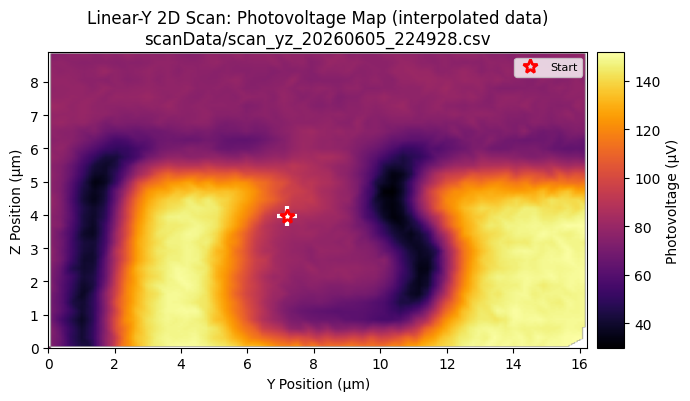

   Total points loaded: 2030
   Y range: 0.00 to 16.23 µm
   Z range: 0.00 to 8.90 µm
   R range: 29.63 to 151.89 µV
   Scan center position: Y=-1.072 mm, Z=-2.476 mm
   Grid: 58 x 35 = 2030, data points: 2030


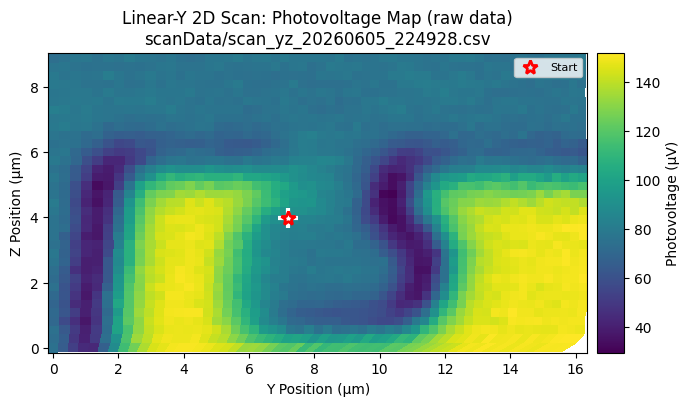

   Y range: 0.00 to 16.23 µm
   Z range: 0.00 to 8.90 µm
   R range: 29.63 to 151.89 µV
   Scan center position: Y=-1.072 mm, Z=-2.476 mm


In [27]:
#scan 14
plotLinear2DScan("scanData/scan_yz_20260605_224928.csv", targetYPositionOffset=0, targetZPositionOffset=0)
plotLinear2DScanPcolormesh("scanData/scan_yz_20260605_224928.csv", targetYPositionOffset=0, targetZPositionOffset=0)

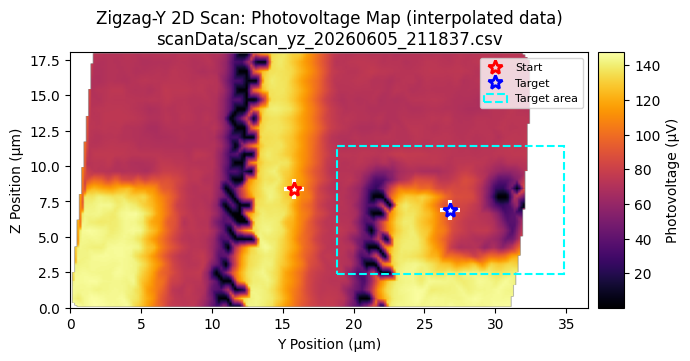

   Total points loaded: 1680
   Y range: 0.00 to 32.57 µm
   Z range: 0.00 to 18.01 µm
   R range: 0.14 to 147.48 µV
   Scan center position: Y=-1.083 mm, Z=-2.475 mm
   Scan target position: Y=-1.072 mm, Z=-2.476 mm
   Target box: Y span=16.00 µm, Z span=9.00 µm
   Grid: 56 x 30 = 1680, data points: 1680


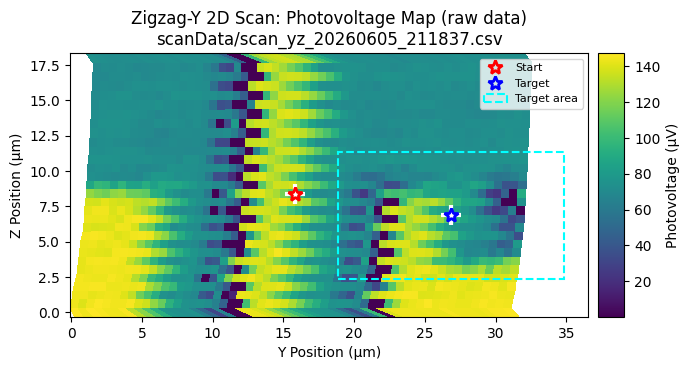

   Y range: 0.00 to 32.57 µm
   Z range: 0.00 to 18.01 µm
   R range: 0.14 to 147.48 µV
   Scan center position: Y=-1.083 mm, Z=-2.475 mm
   Scan target position: Y=-1.072 mm, Z=-2.476 mm
   Target box: Y span=16.00 µm, Z span=9.00 µm


In [24]:
#scan 13
plotZigzag2DScan("scanData/scan_yz_20260605_211837.csv",targetYPositionOffset=11, targetZPositionOffset=-1.5, targetYSpan=16, targetZSpan=9)
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260605_211837.csv",targetYPositionOffset=11, targetZPositionOffset=-1.5, targetYSpan=16, targetZSpan=9)

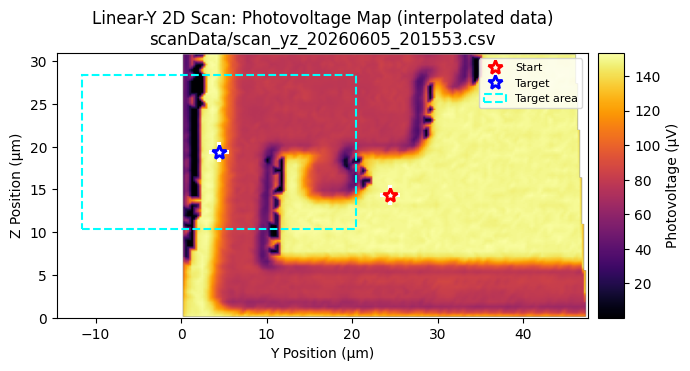

   Total points loaded: 4524
   Y range: 0.00 to 47.58 µm
   Z range: 0.00 to 31.00 µm
   R range: 0.14 to 153.94 µV
   Scan center position: Y=-1.063 mm, Z=-2.480 mm
   Scan target position: Y=-1.083 mm, Z=-2.475 mm
   Target box: Y span=32.00 µm, Z span=18.00 µm
   Grid: 87 x 52 = 4524, data points: 4524


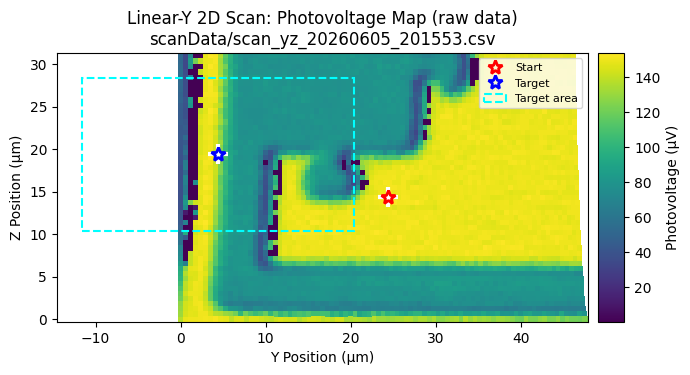

   Y range: 0.00 to 47.58 µm
   Z range: 0.00 to 31.00 µm
   R range: 0.14 to 153.94 µV
   Scan center position: Y=-1.063 mm, Z=-2.480 mm
   Scan target position: Y=-1.083 mm, Z=-2.475 mm
   Target box: Y span=32.00 µm, Z span=18.00 µm


In [28]:
#scan 12
plotLinear2DScan("scanData/scan_yz_20260605_201553.csv", targetYPositionOffset=-20, targetZPositionOffset=5, targetYSpan=32, targetZSpan=18)
plotLinear2DScanPcolormesh("scanData/scan_yz_20260605_201553.csv", targetYPositionOffset=-20, targetZPositionOffset=5, targetYSpan=32, targetZSpan=18)

   Grid: 177 x 74 = 13098, data points: 13098


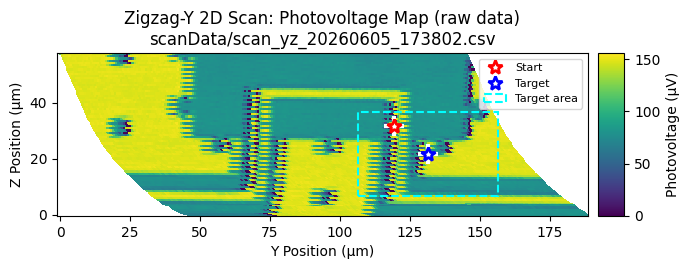

   Y range: 0.00 to 187.72 µm
   Z range: 0.00 to 57.30 µm
   R range: 0.00 to 155.88 µV
   Scan center position: Y=-1.075 mm, Z=-2.470 mm
   Scan target position: Y=-1.063 mm, Z=-2.480 mm
   Target box: Y span=50.00 µm, Z span=30.00 µm


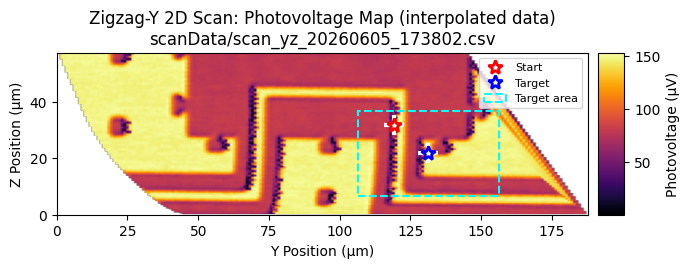

   Total points loaded: 13098
   Y range: 0.00 to 187.72 µm
   Z range: 0.00 to 57.30 µm
   R range: 0.00 to 155.88 µV
   Scan center position: Y=-1.075 mm, Z=-2.470 mm
   Scan target position: Y=-1.063 mm, Z=-2.480 mm
   Target box: Y span=50.00 µm, Z span=30.00 µm


In [35]:
#scan 11
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260605_173802.csv",targetYPositionOffset=12, targetZPositionOffset=-10, targetYSpan=50, targetZSpan=30)
plotZigzag2DScan("scanData/scan_yz_20260605_173802.csv",targetYPositionOffset=12, targetZPositionOffset=-10, targetYSpan=50, targetZSpan=30)

   Grid: 57 x 55 = 3135, data points: 3135


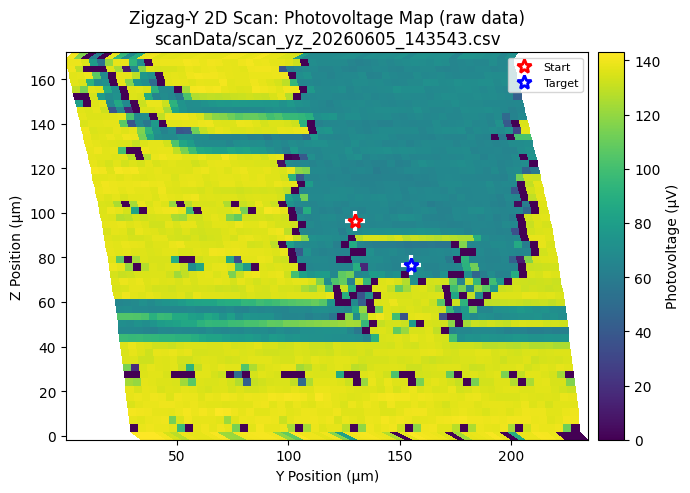

   Y range: 0.00 to 230.88 µm
   Z range: 0.00 to 170.53 µm
   R range: 0.00 to 143.01 µV
   Scan center position: Y=-1.100 mm, Z=-2.450 mm
   Scan target position: Y=-1.075 mm, Z=-2.470 mm


In [30]:
#scan 10
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260605_143543.csv",targetYPositionOffset=25, targetZPositionOffset=-20)

   Grid: 18 x 11 = 198, data points: 198


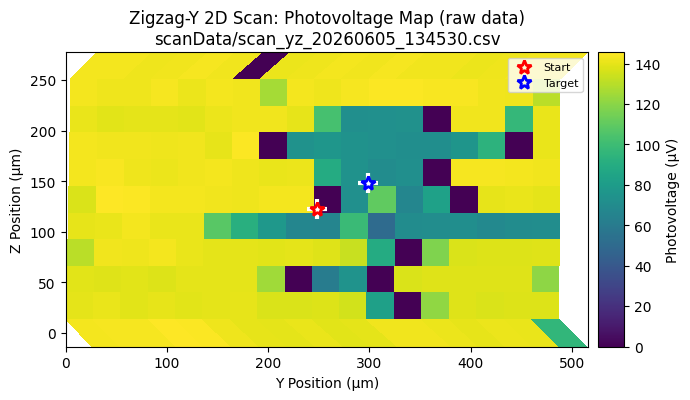

   Y range: 0.00 to 489.35 µm
   Z range: 0.00 to 264.20 µm
   R range: 0.00 to 145.50 µV
   Scan center position: Y=-1.150 mm, Z=-2.475 mm
   Scan target position: Y=-1.100 mm, Z=-2.450 mm


In [31]:
#scan 9
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260605_134530.csv",targetYPositionOffset=50, targetZPositionOffset=25)

   Grid: 30 x 13 = 390, data points: 390


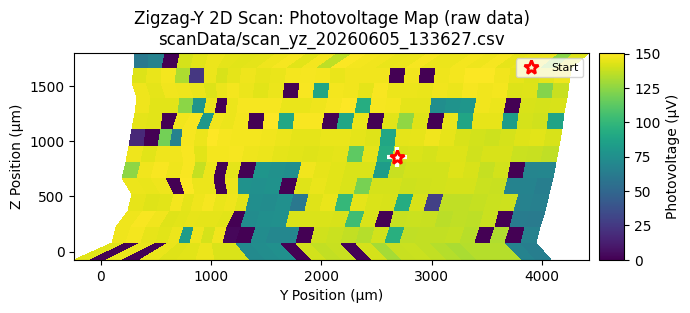

   Y range: 0.00 to 4271.97 µm
   Z range: 0.00 to 1732.77 µm
   R range: 0.00 to 150.51 µV
   Scan center position: Y=-1.150 mm, Z=-2.475 mm


In [32]:
#scan 8
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260605_133627.csv",targetYPositionOffset=0, targetZPositionOffset=0)

   Grid: 110 x 105 = 11550, data points: 11550


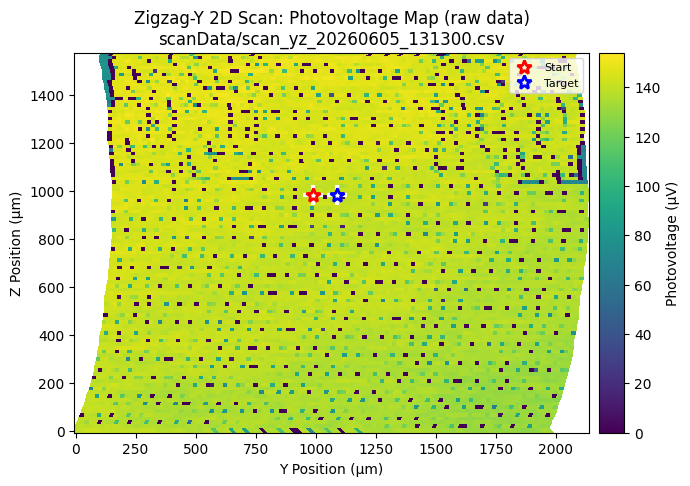

   Y range: 0.00 to 2138.71 µm
   Z range: 0.00 to 1568.73 µm
   R range: 0.00 to 154.04 µV
   Scan center position: Y=-1.250 mm, Z=-4.815 mm
   Scan target position: Y=-1.150 mm, Z=-4.815 mm


In [33]:
#scan 7
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260605_131300.csv",targetYPositionOffset=100, targetZPositionOffset=0)

   Grid: 83 x 8 = 664, data points: 664


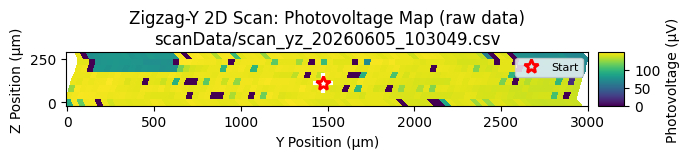

   Y range: 0.00 to 3004.68 µm
   Z range: 0.00 to 270.08 µm
   R range: 0.00 to 149.96 µV
   Scan center position: Y=-1.250 mm, Z=-4.820 mm


In [34]:
#scan 6
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260605_103049.csv",targetYPositionOffset=0, targetZPositionOffset=0)

   Grid: 22 x 21 = 462, data points: 462


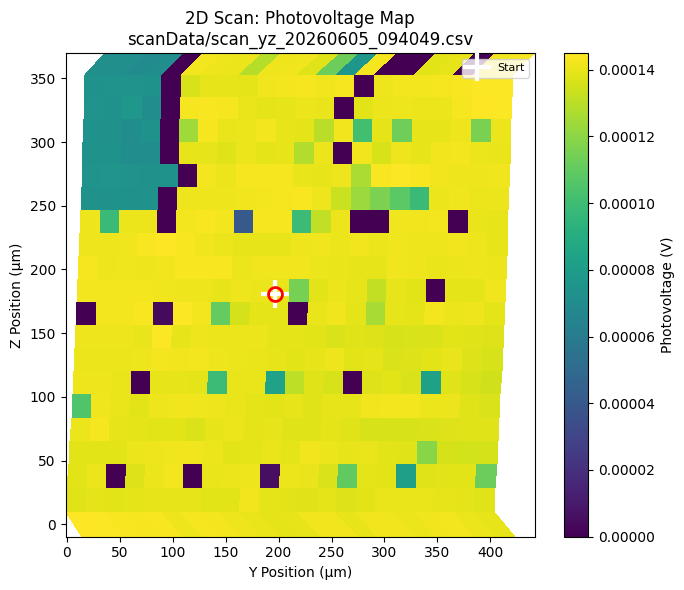

   Y range: 0.00 to 422.02 µm
   Z range: 0.00 to 361.11 µm
   Scan center position: Y=-2.000 mm, Z=-4.820 mm


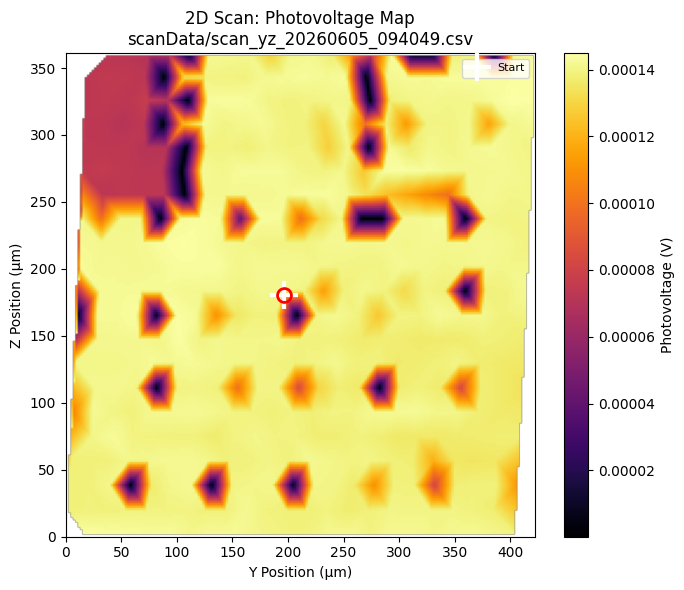

   Total points loaded: 462
   Y range: 0.00 to 422.02 µm
   Z range: 0.00 to 361.11 µm
   Scan center position: Y=196.74 µm, Z=180.68 µm


In [ ]:
#scan 5
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260605_094049.csv")
plotZigzag2DScan("scanData/scan_yz_20260605_094049.csv")

[[-1.18691539 -1.18528346 -1.18375946 ... -1.11003896 -1.10881444
  -1.10758438]
 [-1.18932805 -1.18817757 -1.18702781 ... -1.11276286 -1.11114836
  -1.10942556]
 [-1.18753662 -1.18587733 -1.18433291 ... -1.10940721 -1.10816905
  -1.10693217]
 ...
 [-1.18211941 -1.18054051 -1.17902214 ... -1.10068786 -1.09945684
  -1.09823366]
 [-1.18353306 -1.18231948 -1.1810983  ... -1.10314852 -1.10159203
  -1.0999497 ]
 [-1.18186289 -1.18028576 -1.17877162 ... -1.10039265 -1.09916568
  -1.09793686]]


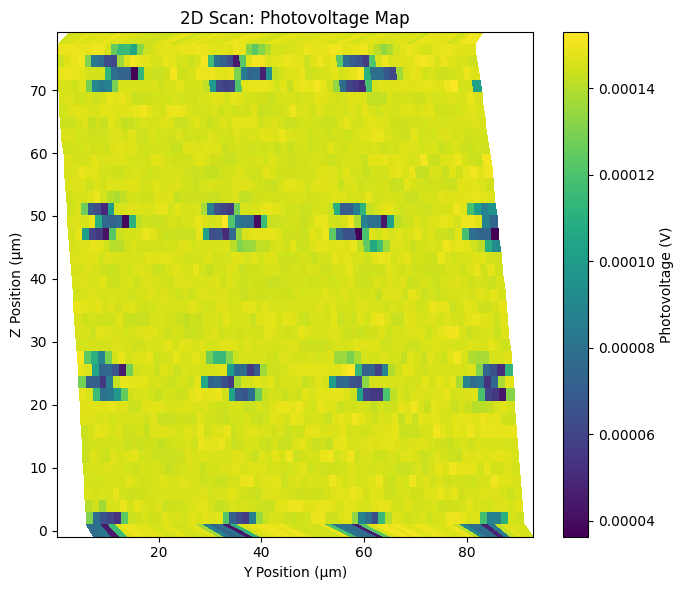

In [63]:
import matplotlib.pyplot as plt
import numpy as np

y, z, r = np.loadtxt("scanData/scan_yz_20260604_122343.csv", delimiter=",", skiprows=1, unpack=True)

n_y, n_z = 64, 41
Y = y.reshape(n_z, n_y)
Z = z.reshape(n_z, n_y)
R = r.reshape(n_z, n_y)

# Snake correction — must apply to all three
Y[1::2, :] = Y[1::2, ::-1]
Z[1::2, :] = Z[1::2, ::-1]
R[1::2, :] = R[1::2, ::-1]

print(Y)

# Convert to microns — keep as 2D for pcolormesh
Y_um = (Y - Y.min()) * 1000
Z_um = (Z - Z.min()) * 1000

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(Y_um, Z_um, R, shading='auto', cmap='viridis')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Photovoltage (V)')
ax.set_xlabel('Y Position (µm)')
ax.set_ylabel('Z Position (µm)')
ax.set_title('2D Scan: Photovoltage Map')
plt.tight_layout()
plt.show()


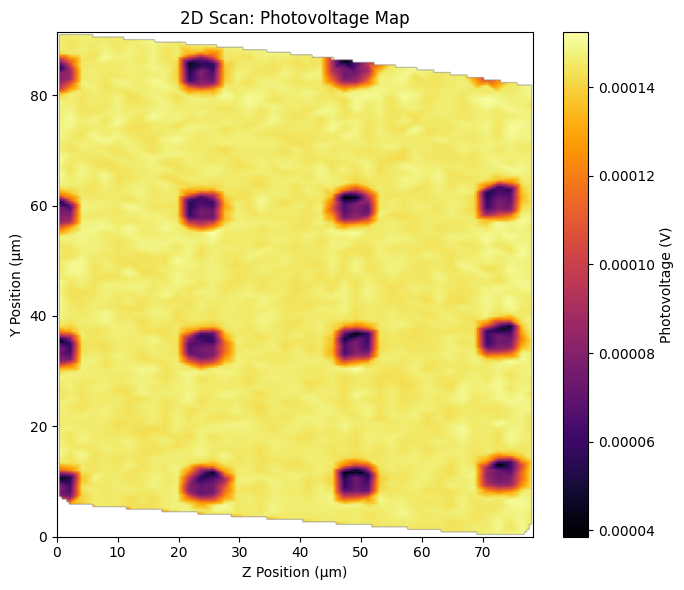

   Total points loaded: 2624
   Y range: 0.0000 to 91.3912 mm
   Z range: 0.0000 to 78.2759 mm


In [50]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

y, z, r = np.loadtxt("scanData/scan_yz_20260604_122343.csv", delimiter=",", skiprows=1, unpack=True)
mask = (y != 0)
y = (y[mask] - y.min()) * 1000  # Shift to start at 0
z = (z[mask] - z.min()) * 1000  # Shift to start at 0
r = r[mask]

# Interpolate onto a regular grid
resolution = 200
z_grid, y_grid = np.meshgrid(np.linspace(z.min(), z.max(), resolution),
                              np.linspace(y.min(), y.max(), resolution))
R_grid = griddata((z, y), r, (z_grid, y_grid), method='linear')

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(R_grid,
               extent=[z.min(), z.max(), y.min(), y.max()],
               origin='lower',
               aspect='auto',
               cmap='inferno')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Photovoltage (V)')
ax.set_xlabel('Z Position (µm)')
ax.set_ylabel('Y Position (µm)')
ax.set_title('2D Scan: Photovoltage Map')
plt.tight_layout()
plt.show()

print(f"   Total points loaded: {len(r)}")
print(f"   Y range: {y.min():.4f} to {y.max():.4f} mm")
print(f"   Z range: {z.min():.4f} to {z.max():.4f} mm")

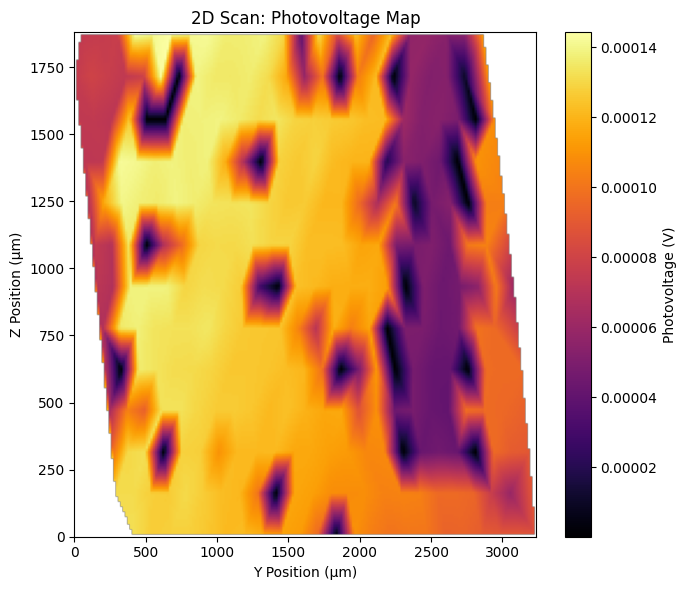

   Total points loaded: 299
   Y range: 0.00 to 3239.40 µm
   Z range: 0.00 to 1879.85 µm


In [54]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

y, z, r = np.loadtxt("scanData/scan_yz_20260604_151520.csv", delimiter=",", skiprows=1, unpack=True)
mask = (y != 0)
y = (y[mask] - y[mask].min()) * 1000  # Shift to start at 0
z = (z[mask] - z[mask].min()) * 1000  # Shift to start at 0
r = r[mask]

# Interpolate onto a regular grid
resolution = 200
y_grid, z_grid = np.meshgrid(np.linspace(y.min(), y.max(), resolution),
                              np.linspace(z.min(), z.max(), resolution))
R_grid = griddata((y, z), r, (y_grid, z_grid), method='linear')

# Plot — y is x-axis, z is y-axis
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(R_grid,
               extent=[y.min(), y.max(), z.min(), z.max()],
               origin='lower',
               aspect='auto',
               cmap='inferno')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Photovoltage (V)')
ax.set_xlabel('Y Position (µm)')
ax.set_ylabel('Z Position (µm)')
ax.set_title('2D Scan: Photovoltage Map')
plt.tight_layout()
plt.show()

print(f"   Total points loaded: {len(r)}")
print(f"   Y range: {y.min():.2f} to {y.max():.2f} µm")
print(f"   Z range: {z.min():.2f} to {z.max():.2f} µm")

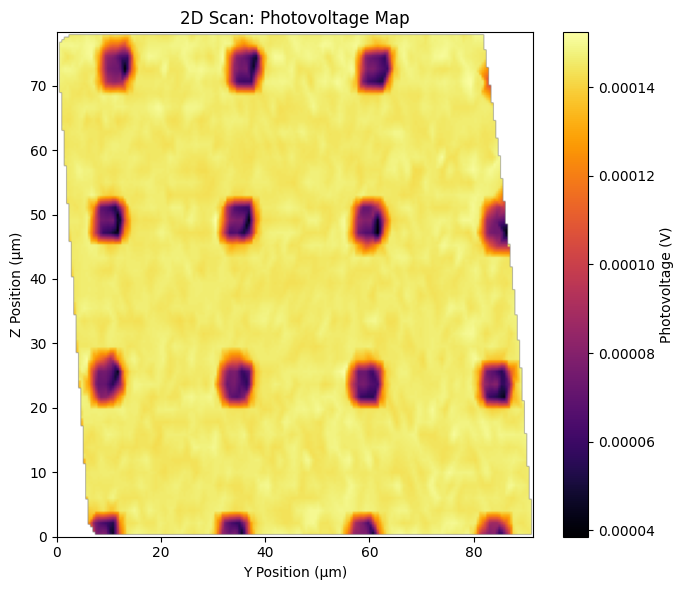

   Total points loaded: 2624
   Y range: 0.00 to 91.39 µm
   Z range: 0.00 to 78.28 µm


In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

y, z, r = np.loadtxt("scanData/scan_yz_20260604_122343.csv", delimiter=",", skiprows=1, unpack=True)
mask = (y != 0)
y = (y[mask] - y[mask].min()) * 1000  # Shift to start at 0
z = (z[mask] - z[mask].min()) * 1000  # Shift to start at 0
r = r[mask]

# Interpolate onto a regular grid
resolution = 200
y_grid, z_grid = np.meshgrid(np.linspace(y.min(), y.max(), resolution),
                              np.linspace(z.min(), z.max(), resolution))
R_grid = griddata((y, z), r, (y_grid, z_grid), method='linear')

# Plot — y is x-axis, z is y-axis
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(R_grid,
               extent=[y.min(), y.max(), z.min(), z.max()],
               origin='lower',
               aspect='auto',
               cmap='inferno')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Photovoltage (V)')
ax.set_xlabel('Y Position (µm)')
ax.set_ylabel('Z Position (µm)')
ax.set_title('2D Scan: Photovoltage Map')
plt.tight_layout()
plt.show()

print(f"   Total points loaded: {len(r)}")
print(f"   Y range: {y.min():.2f} to {y.max():.2f} µm")
print(f"   Z range: {z.min():.2f} to {z.max():.2f} µm")


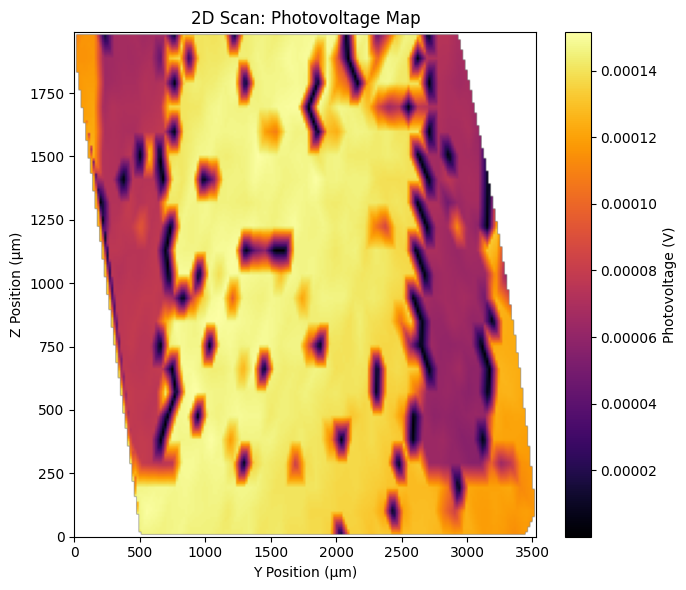

   Total points loaded: 858
   Y range: 0.00 to 3530.74 µm
   Z range: 0.00 to 1989.27 µm


In [69]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

y, z, r = np.loadtxt("scanData/scan_yz_20260604_153757.csv", delimiter=",", skiprows=1, unpack=True)
mask = (y != 0)
y = (y[mask] - y[mask].min()) * 1000  # Shift to start at 0
z = (z[mask] - z[mask].min()) * 1000  # Shift to start at 0
r = r[mask]

# Interpolate onto a regular grid
resolution = 200
y_grid, z_grid = np.meshgrid(np.linspace(y.min(), y.max(), resolution),
                              np.linspace(z.min(), z.max(), resolution))
R_grid = griddata((y, z), r, (y_grid, z_grid), method='linear')

# Plot — y is x-axis, z is y-axis
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(R_grid,
               extent=[y.min(), y.max(), z.min(), z.max()],
               origin='lower',
               aspect='auto',
               cmap='inferno')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Photovoltage (V)')
ax.set_xlabel('Y Position (µm)')
ax.set_ylabel('Z Position (µm)')
ax.set_title('2D Scan: Photovoltage Map')
plt.tight_layout()
plt.show()

print(f"   Total points loaded: {len(r)}")
print(f"   Y range: {y.min():.2f} to {y.max():.2f} µm")
print(f"   Z range: {z.min():.2f} to {z.max():.2f} µm")

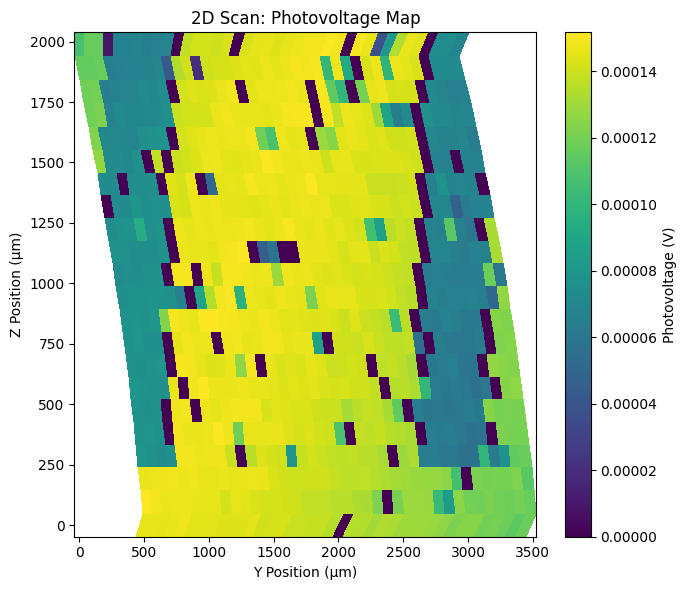

In [64]:
import matplotlib.pyplot as plt
import numpy as np

y, z, r = np.loadtxt("scanData/scan_yz_20260604_153757.csv", delimiter=",", skiprows=1, unpack=True)

n_y, n_z = 39, 22
Y = y.reshape(n_z, n_y)
Z = z.reshape(n_z, n_y)
R = r.reshape(n_z, n_y)

# Snake correction — must apply to all three
Y[1::2, :] = Y[1::2, ::-1]
Z[1::2, :] = Z[1::2, ::-1]
R[1::2, :] = R[1::2, ::-1]

# Convert to microns — keep as 2D for pcolormesh
Y_um = (Y - Y.min()) * 1000
Z_um = (Z - Z.min()) * 1000

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(Y_um, Z_um, R, shading='auto', cmap='viridis')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Photovoltage (V)')
ax.set_xlabel('Y Position (µm)')
ax.set_ylabel('Z Position (µm)')
ax.set_title('2D Scan: Photovoltage Map')
plt.tight_layout()
plt.show()


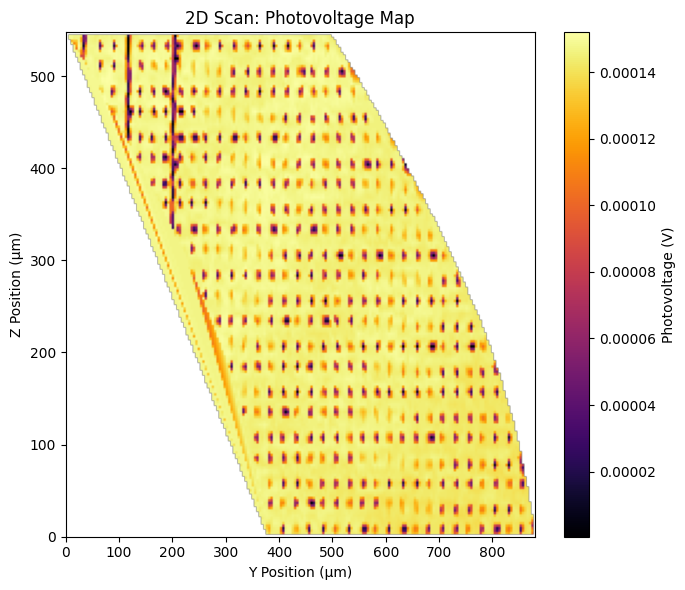

   Total points loaded: 7410
   Y range: 0.00 to 879.15 µm
   Z range: 0.00 to 547.51 µm


In [60]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

y, z, r = np.loadtxt("scanData/scan_yz_20260604_174851.csv", delimiter=",", skiprows=1, unpack=True)
mask = (y != 0)
y = (y[mask] - y[mask].min()) * 1000  # Shift to start at 0
z = (z[mask] - z[mask].min()) * 1000  # Shift to start at 0
r = r[mask]

# Interpolate onto a regular grid
resolution = 200
y_grid, z_grid = np.meshgrid(np.linspace(y.min(), y.max(), resolution),
                              np.linspace(z.min(), z.max(), resolution))
R_grid = griddata((y, z), r, (y_grid, z_grid), method='linear')

# Plot — y is x-axis, z is y-axis
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(R_grid,
               extent=[y.min(), y.max(), z.min(), z.max()],
               origin='lower',
               aspect='auto',
               cmap='inferno')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Photovoltage (V)')
ax.set_xlabel('Y Position (µm)')
ax.set_ylabel('Z Position (µm)')
ax.set_title('2D Scan: Photovoltage Map')
plt.tight_layout()
plt.show()

print(f"   Total points loaded: {len(r)}")
print(f"   Y range: {y.min():.2f} to {y.max():.2f} µm")
print(f"   Z range: {z.min():.2f} to {z.max():.2f} µm")

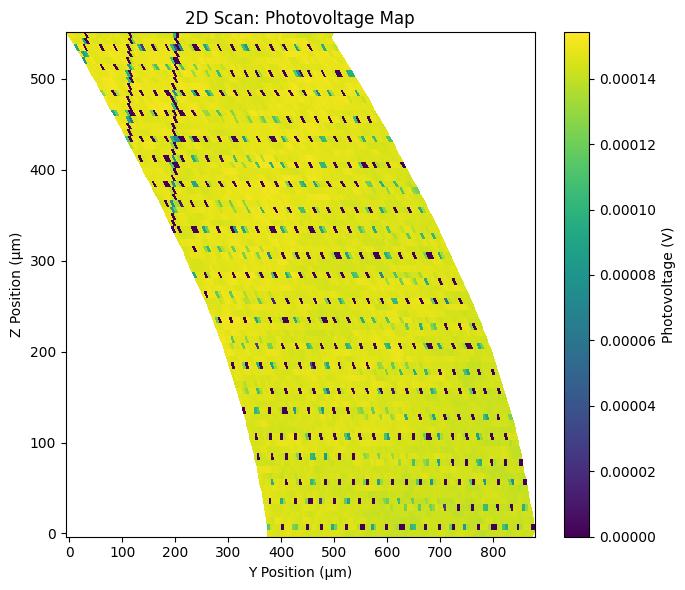

In [65]:
import matplotlib.pyplot as plt
import numpy as np

y, z, r = np.loadtxt("scanData/scan_yz_20260604_174851.csv", delimiter=",", skiprows=1, unpack=True)

n_y, n_z = 95, 78
Y = y.reshape(n_z, n_y)
Z = z.reshape(n_z, n_y)
R = r.reshape(n_z, n_y)

# Snake correction — must apply to all three
Y[1::2, :] = Y[1::2, ::-1]
Z[1::2, :] = Z[1::2, ::-1]
R[1::2, :] = R[1::2, ::-1]

# Convert to microns — keep as 2D for pcolormesh
Y_um = (Y - Y.min()) * 1000
Z_um = (Z - Z.min()) * 1000

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(Y_um, Z_um, R, shading='auto', cmap='viridis')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Photovoltage (V)')
ax.set_xlabel('Y Position (µm)')
ax.set_ylabel('Z Position (µm)')
ax.set_title('2D Scan: Photovoltage Map')
plt.tight_layout()
plt.show()


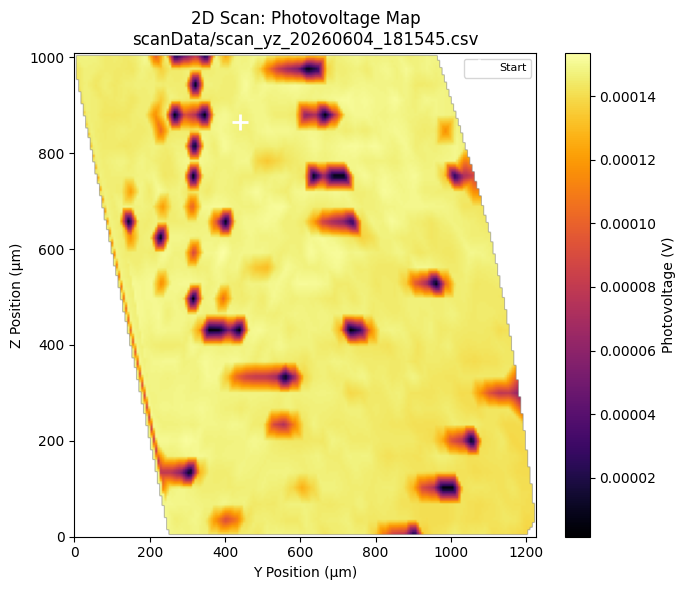

   Total points loaded: 1184
   Y range: 0.00 to 1227.04 µm
   Z range: 0.00 to 1008.72 µm
   Start position: Y=440.20 µm, Z=865.63 µm
   Grid: 37 x 32 = 1184, data points: 1184


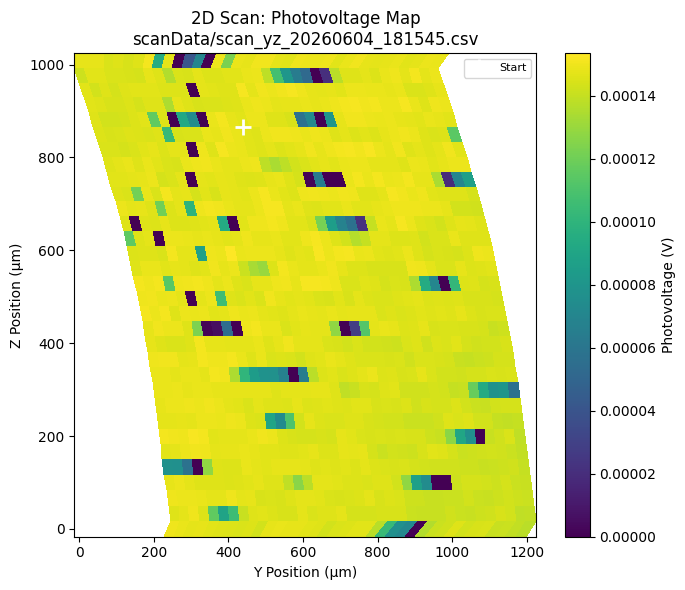

   Y range: 0.00 to 1227.04 µm
   Z range: 0.00 to 1008.72 µm
   Start position: Y=440.20 µm, Z=865.63 µm


In [ ]:
plotZigzag2DScan("scanData/scan_yz_20260604_181545.csv")
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260604_181545.csv")


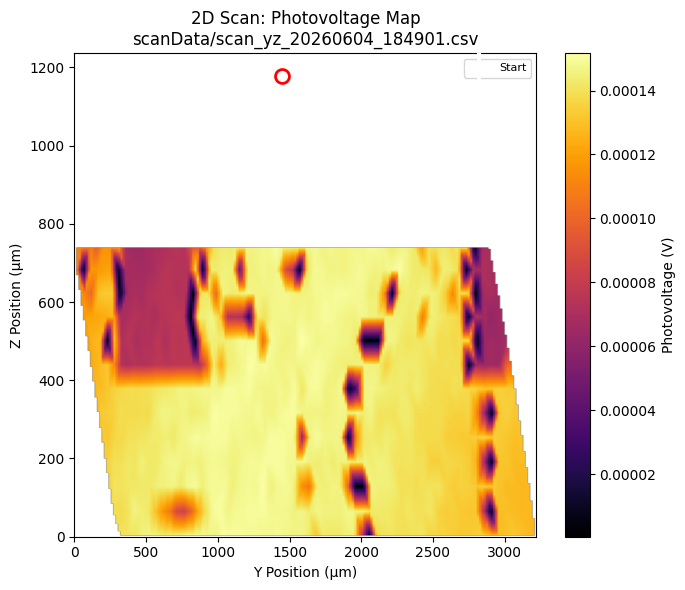

   Total points loaded: 728
   Y range: 0.00 to 3221.61 µm
   Z range: 0.00 to 743.82 µm
   Start position: Y=1447.69 µm, Z=1177.46 µm
   Grid: 56 x 13 = 728, data points: 728


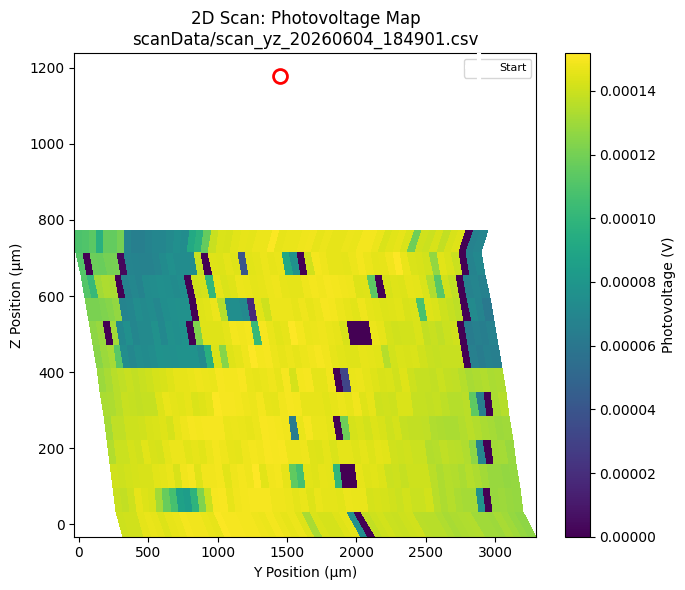

   Y range: 0.00 to 3221.61 µm
   Z range: 0.00 to 743.82 µm
   Start position: Y=1447.69 µm, Z=1177.46 µm


In [ ]:
plotZigzag2DScan("scanData/scan_yz_20260604_184901.csv")
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260604_184901.csv")

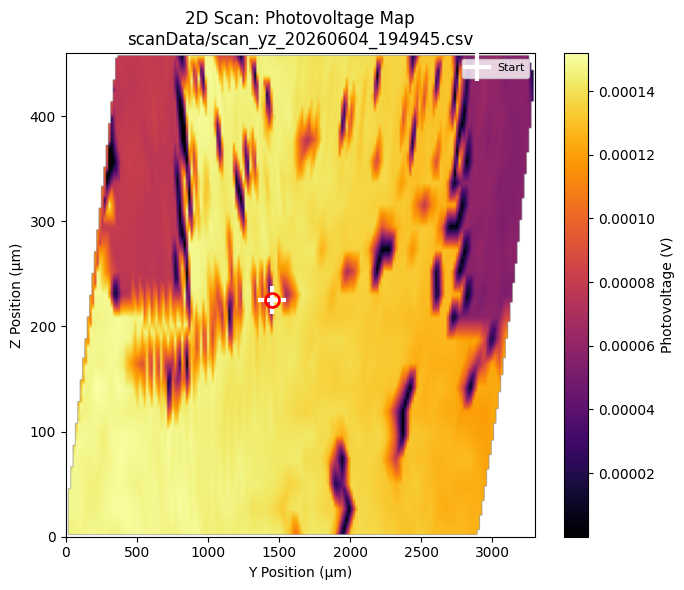

   Total points loaded: 1232
   Y range: 0.00 to 3298.47 µm
   Z range: 0.00 to 459.95 µm
   Scan center position: Y=1448.77 µm, Z=224.83 µm
   Grid: 56 x 22 = 1232, data points: 1232


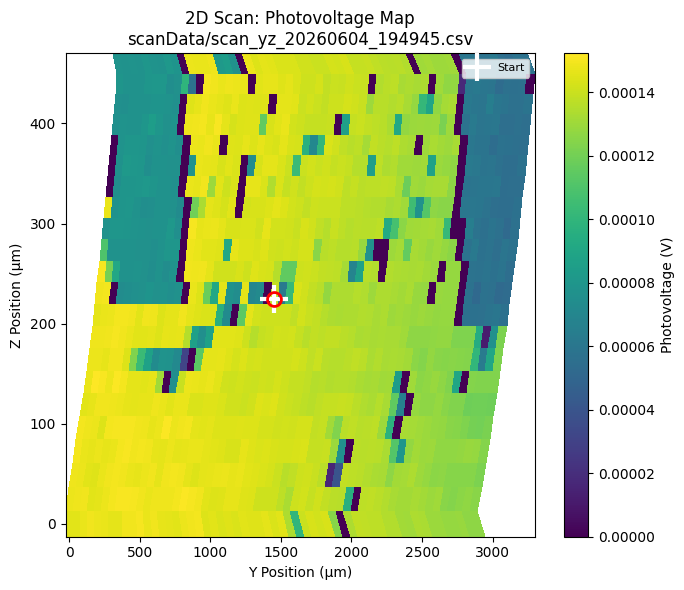

   Y range: 0.00 to 3298.47 µm
   Z range: 0.00 to 459.95 µm
   Scan center position: Y=-1.500 mm, Z=-4.750 mm


In [ ]:
plotZigzag2DScan("scanData/scan_yz_20260604_194945.csv")
plotZigzag2DScanPcolormesh("scanData/scan_yz_20260604_194945.csv")